In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df_index = pd.read_csv('data/economic_index.csv')

In [4]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
# drop unnecessary columns
df_index.drop(columns=['Unnamed: 0','year','month'], inplace=True)

In [6]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [7]:
# check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

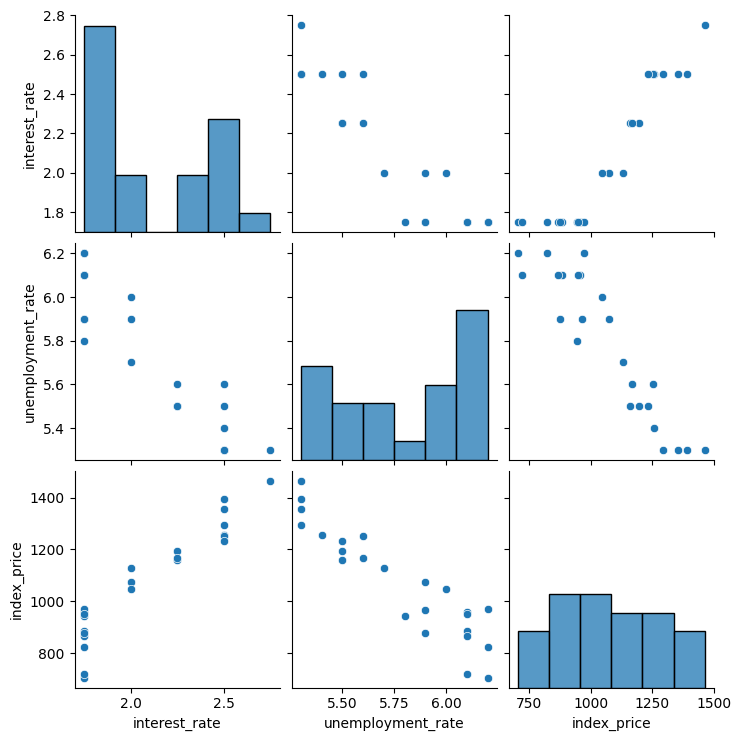

In [9]:
sns.pairplot(df_index)

In [10]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

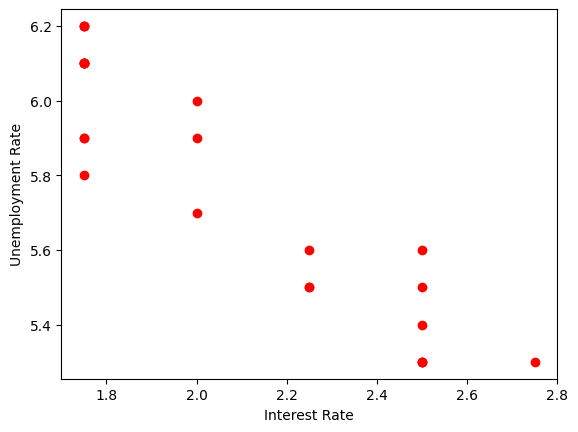

In [11]:
# visualiza the datapoints more closely
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='red')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')

In [12]:
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [14]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [15]:
# train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

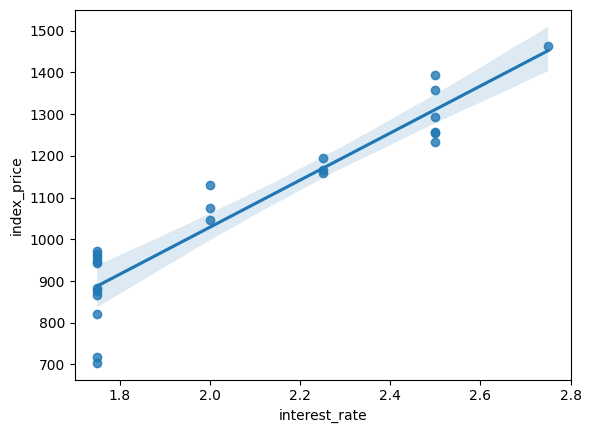

In [18]:
sns.regplot(x='interest_rate', y='index_price', data=df_index)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

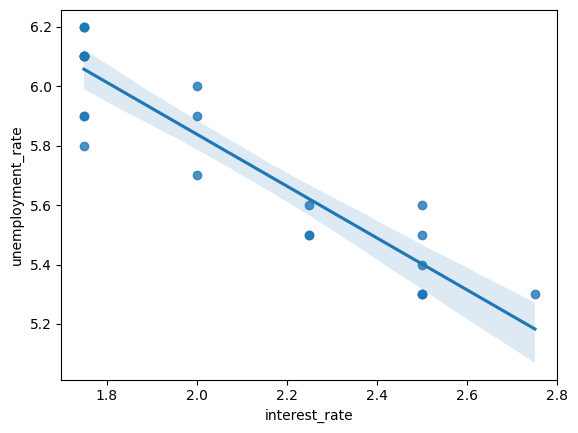

In [19]:
sns.regplot(x='interest_rate', y='unemployment_rate', data=df_index)

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

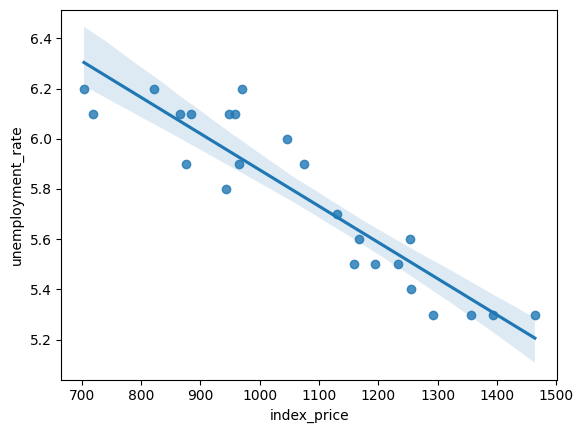

In [20]:
sns.regplot(x='index_price', y='unemployment_rate', data=df_index)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train_scaled, y_train)

LinearRegression()

In [23]:
from sklearn.model_selection import cross_val_score
# thư viện này dùng để đánh giá mô hình thông qua cách như sau 
# bình thường dữ liệu sẽ được chia thành 2 phần là train và test
# nhưng với thư viện này thì dữ liệu train sẽ được chia thành nhiều phần nhỏ
# ví dụ nếu cv=5 thì dữ liệu train sẽ được chia thành 5 phần
# và lặp 5 lần, với k = 1 thì sẽ lấy phần 1 làm dữ liệu test còn 4 phần còn lại làm dữ liệu train
validation_scores = cross_val_score(model, X_train_scaled, y_train,scoring='neg_mean_squared_error', cv=3)

In [25]:
np.mean(validation_scores)

np.float64(-5914.828180162386)

In [41]:
# prediction
y_pred = regression.predict(X_test_scaled)

In [42]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [43]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712569
59.935781523235484
76.11677139574805


In [44]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
#display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test_scaled.shape[1]-1))

0.8278978091457145
0.7131630152428576


## Assumptions

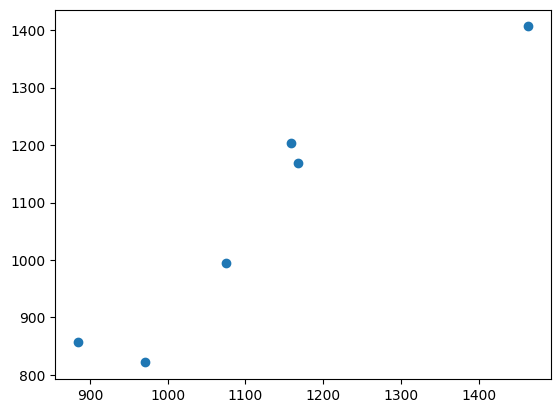

In [31]:
plt.scatter(y_test,y_pred)

In [32]:
residuals = y_test - y_pred
residuals

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64

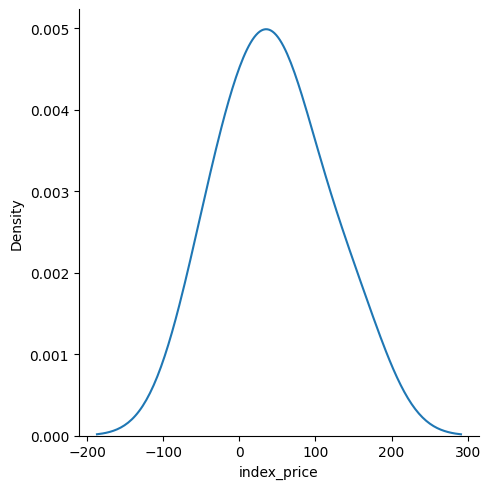

In [33]:
# plot this residuals
sns.displot(residuals,kind='kde')

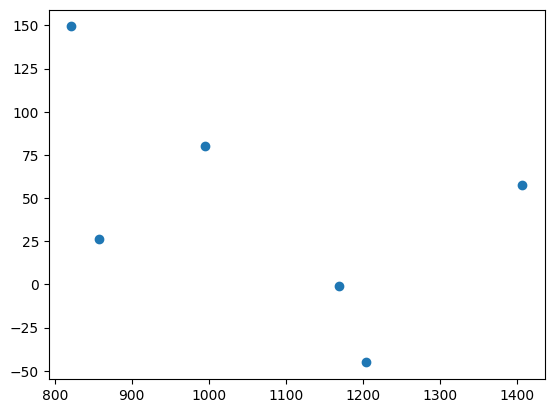

In [34]:
# scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

In [36]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train_scaled).fit()

In [38]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 17 Jul 2025   Prob (F-statistic):                       0.754
Time:                        20:40:22   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [45]:
print(regression.coef_)

[  88.27275507 -116.25716066]
